# IndoNewsClassifier

EDA → preprocessing → baseline → transformer fine-tune → evaluation → comparison

## 1. Setup

In [1]:
import sys
from pathlib import Path

# --- Colab bootstrap (no-op locally, and safe to re-run) ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not Path('../src').is_dir():
    if not Path('IndoNewsClassifier').exists():
        get_ipython().system('git clone -q https://github.com/aljuhaeda/IndoNewsClassifier.git')
    get_ipython().run_line_magic('cd', 'IndoNewsClassifier/notebooks')
    get_ipython().system('pip install -q Sastrawi wordcloud')

if IN_COLAB:
    raw_path = Path('../data/raw/detik_news_title.csv')
    if not raw_path.exists():
        raw_path.parent.mkdir(parents=True, exist_ok=True)
        get_ipython().system('curl -sL -o ../data/raw/detik_news_title.csv https://raw.githubusercontent.com/ibamibrahim/dataset-judul-berita-indonesia/master/detik_news_title.csv')

print('Running on Colab:', IN_COLAB)

sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_dataset, clean_text, light_clean_text, get_stopwords, split_dataset
from src.training import train_baseline, evaluate_baseline, save_baseline

DATA_PATH = Path('../data/raw/detik_news_title.csv')
DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')


/content/IndoNewsClassifier/notebooks
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.2 MB/s eta 0:00:00
Running on Colab: True


## 2. EDA

Class balance, title length distribution, word clouds, missing/duplicate check.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print('Shape:', df_raw.shape)
print()
print('Missing values per column:')
print(df_raw.isna().sum())
print()
n_dupes = df_raw.duplicated(subset=['title']).sum()
print(f'Duplicate titles: {n_dupes}')
print()
print('Date range:', df_raw['date'].min(), '-', df_raw['date'].max())


Shape: (91017, 4)

Missing values per column:
date        0
url         0
title       0
category    0
dtype: int64

Duplicate titles: 126

Date range: 01/01/2020 - 06/13/2020


Rows after dropping 126 duplicate titles: 90891


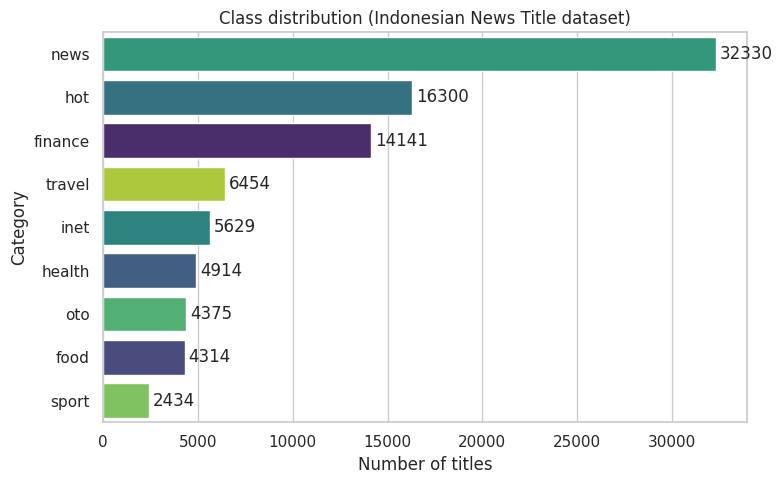

Imbalance ratio (largest/smallest class): 13.3x


In [3]:
# Drop duplicate titles before any further EDA/modeling
df = df_raw.drop_duplicates(subset=['title']).reset_index(drop=True)
print(f'Rows after dropping {n_dupes} duplicate titles: {len(df)}')

order = df['category'].value_counts().index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, y='category', order=order, ax=ax, hue='category', palette='viridis', legend=False)
ax.set_title('Class distribution (Indonesian News Title dataset)')
ax.set_xlabel('Number of titles')
ax.set_ylabel('Category')
for i, cat in enumerate(order):
    count = (df['category'] == cat).sum()
    ax.text(count + 200, i, str(count), va='center')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = df['category'].value_counts().max() / df['category'].value_counts().min()
print(f'Imbalance ratio (largest/smallest class): {imbalance_ratio:.1f}x')


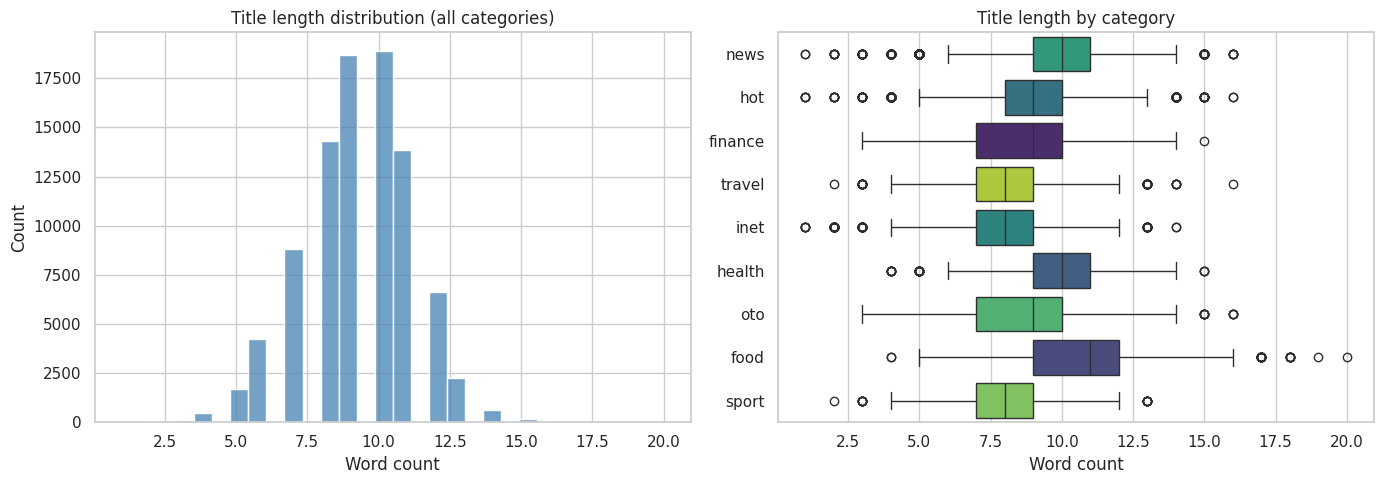

count    90891.000000
mean         9.277684
std          1.888574
min          1.000000
25%          8.000000
50%          9.000000
75%         11.000000
max         20.000000
Name: title_word_count, dtype: float64


In [4]:
df['title_word_count'] = df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['title_word_count'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Title length distribution (all categories)')
axes[0].set_xlabel('Word count')

sns.boxplot(data=df, x='title_word_count', y='category', order=order, ax=axes[1], hue='category', palette='viridis', legend=False)
axes[1].set_title('Title length by category')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'title_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['title_word_count'].describe())


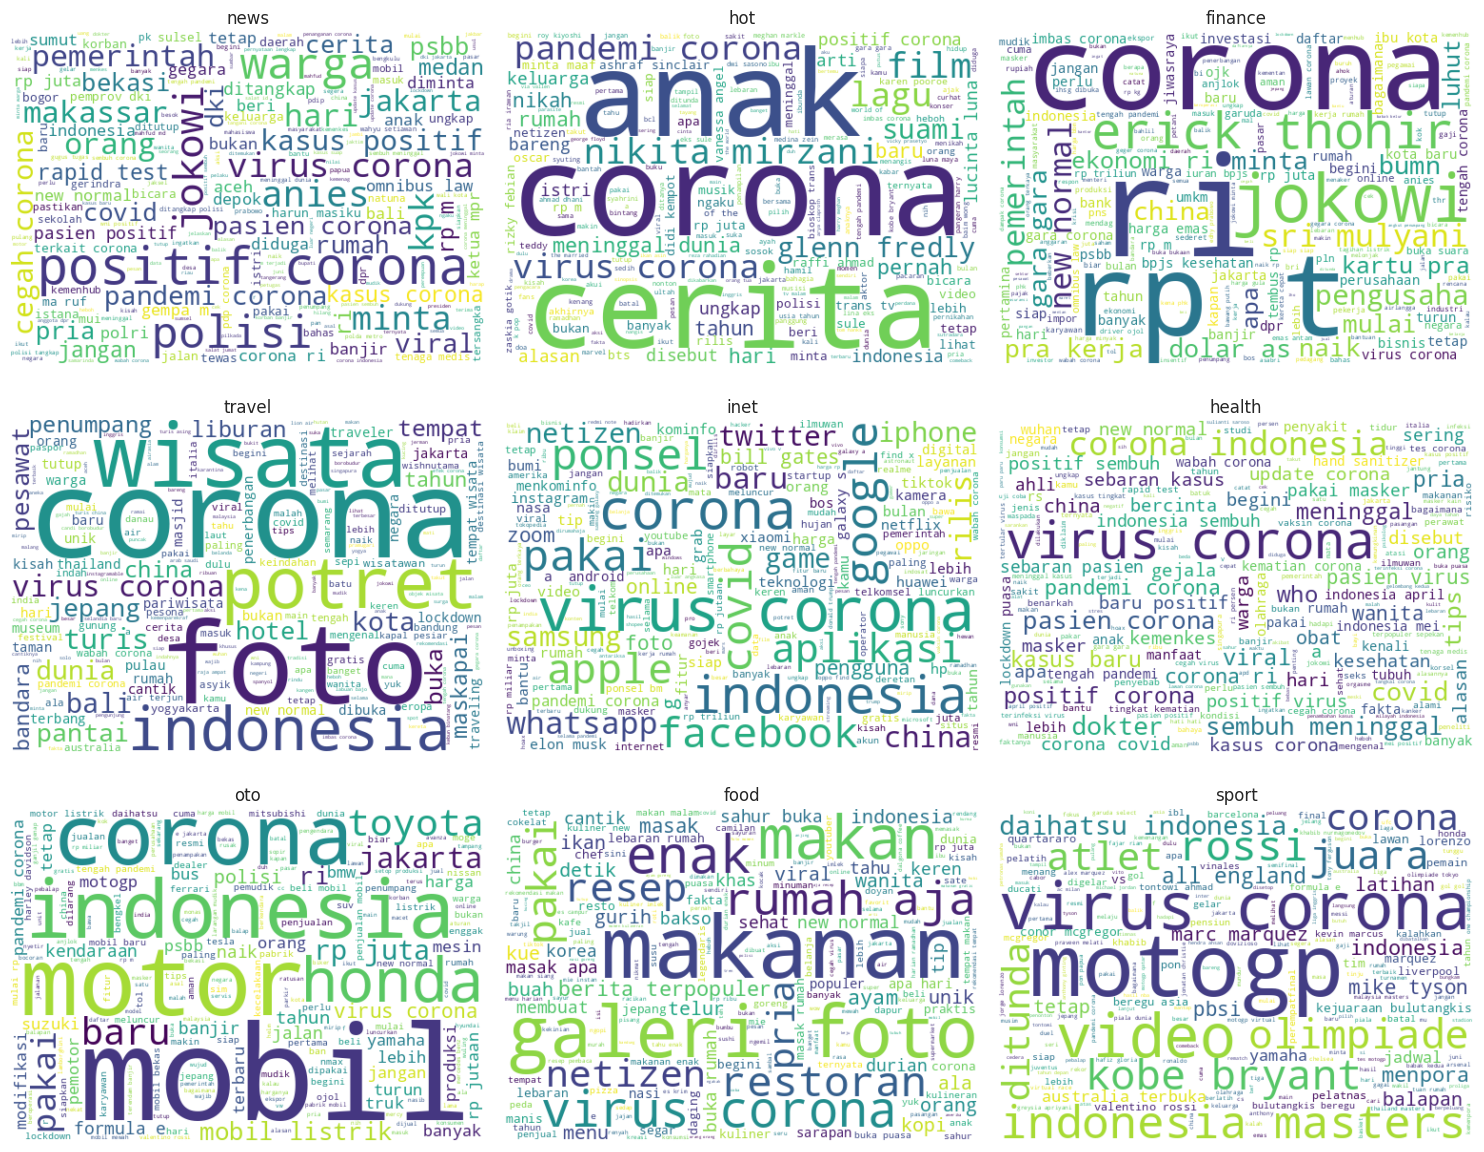

In [5]:
from wordcloud import WordCloud

id_stopwords = get_stopwords()

df['title_clean'] = df['title'].apply(lambda t: clean_text(t, stopwords=id_stopwords))

categories = order.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, cat in zip(axes.flat, categories):
    text = ' '.join(df.loc[df['category'] == cat, 'title_clean'])
    wc = WordCloud(
        width=500, height=350, background_color='white',
        stopwords=id_stopwords, colormap='viridis',
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat)
    ax.axis('off')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


### EDA findings

- **91,017 rows → 90,891 after dropping 126 duplicate titles.** No missing values.
- **Class imbalance is significant**: `news` (32,330) vs `sport` (2,434), a ~13.3x ratio. Macro-F1 (not accuracy) is the right primary metric, and `class_weight="balanced"` is used for the baseline.
- **Data only spans Jan–Jun 2020** — the collection window overlaps COVID-19 onset in Indonesia, so "corona"/"virus"/"pandemi" appear as top words across nearly every category (finance, health, travel, sport, food, oto). This is a real limitation: the model's vocabulary is skewed toward one global event rather than representative of news in general. Noted in the final README.
- **Stopword leakage**: Sastrawi's default Indonesian stopword list missed common informal/journalistic filler words (`tak`, `jadi`, `bikin`, `soal`, `hingga`, `usai`). Extending the stopword list below before modeling.

## 3. Preprocessing

In [6]:
# title_clean: aggressively cleaned (lowercased, punctuation + stopwords stripped) for the TF-IDF baseline
# title_light_clean: URLs/whitespace only, casing and stopwords intact, for IndoBERT
df['title_clean'] = df['title'].apply(lambda t: clean_text(t, stopwords=id_stopwords))
df['title_light_clean'] = df['title'].apply(light_clean_text)

# drop titles that became empty after aggressive cleaning (all-stopword titles)
empty_after_clean = (df['title_clean'].str.len() == 0).sum()
df = df[df['title_clean'].str.len() > 0].reset_index(drop=True)
print(f'Dropped {empty_after_clean} titles that were empty after cleaning')
print(f'Final dataset size: {len(df)}')

train_df, val_df, test_df = split_dataset(df)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

train_df.to_csv('../data/processed_train.csv', index=False)
val_df.to_csv('../data/processed_val.csv', index=False)
test_df.to_csv('../data/processed_test.csv', index=False)


Dropped 0 titles that were empty after cleaning
Final dataset size: 90891
Train: 63623  Val: 13634  Test: 13634


## 4. Baseline: TF-IDF + Logistic Regression

In [7]:
baseline_pipeline = train_baseline(train_df)

val_report, val_cm, labels = evaluate_baseline(baseline_pipeline, val_df)
test_report, test_cm, _ = evaluate_baseline(baseline_pipeline, test_df)

print('=== Validation set ===')
print(f"Accuracy: {val_report['accuracy']:.4f}")
print(f"Macro F1: {val_report['macro avg']['f1-score']:.4f}")
print()
print('=== Test set ===')
print(f"Accuracy: {test_report['accuracy']:.4f}")
print(f"Macro F1: {test_report['macro avg']['f1-score']:.4f}")
print()

per_class = pd.DataFrame(test_report).T.loc[labels, ['precision', 'recall', 'f1-score', 'support']]
print('Per-class metrics (test set):')
print(per_class.round(3))


=== Validation set ===
Accuracy: 0.8262
Macro F1: 0.8017

=== Test set ===
Accuracy: 0.8279
Macro F1: 0.8000

Per-class metrics (test set):
         precision  recall  f1-score  support
finance      0.811   0.826     0.818   2122.0
food         0.809   0.839     0.824    647.0
health       0.604   0.810     0.692    737.0
hot          0.896   0.901     0.899   2445.0
inet         0.746   0.778     0.762    844.0
news         0.928   0.806     0.863   4850.0
oto          0.711   0.835     0.768    656.0
sport        0.823   0.852     0.837    365.0
travel       0.690   0.793     0.738    968.0


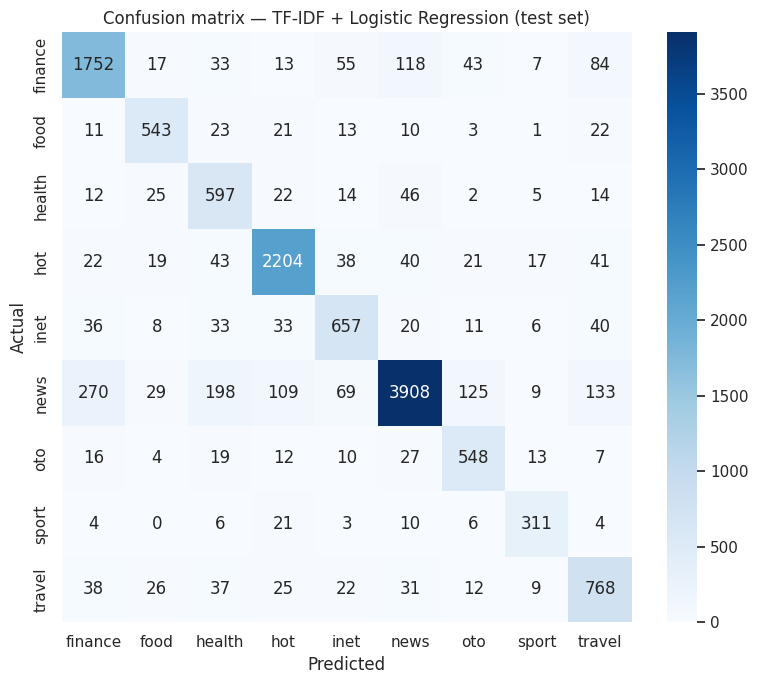

Saved baseline model to models/tfidf_logreg.joblib


In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Confusion matrix — TF-IDF + Logistic Regression (test set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Path('../models').mkdir(exist_ok=True)
save_baseline(baseline_pipeline, '../models/tfidf_logreg.joblib')
print('Saved baseline model to models/tfidf_logreg.joblib')


## 5. Transformer: IndoBERT fine-tune

**Run this section on Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU). Sections 1–4 ran fine on CPU; this section won't finish in reasonable time without a GPU.

Open this notebook in Colab (`File → Open notebook → GitHub → aljuhaeda/IndoNewsClassifier`) and run all cells from the top — Section 1's bootstrap cell clones the repo and downloads the raw dataset automatically, and Sections 2–4 populate `train_df`/`val_df`/`test_df` that this section reuses.

In [9]:
get_ipython().system('pip install -q transformers datasets accelerate')


In [10]:
from src.training import train_indobert, evaluate_indobert

trainer, indobert_tokenizer, label2id, id2label = train_indobert(
    train_df, val_df,
    num_epochs=3,
    learning_rate=2e-5,
    batch_size=16,
)


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/63623 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss
1,0.401566,0.369033
2,0.202130,0.359886
3,0.113794,0.448660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/13634 [00:00<?, ? examples/s]

=== Test set (IndoBERT) ===
Accuracy: 0.8966
Macro F1: 0.8705

Per-class metrics (test set):
         precision  recall  f1-score  support
finance      0.861   0.895     0.878   2122.0
food         0.906   0.895     0.900    647.0
health       0.824   0.788     0.806    737.0
hot          0.926   0.960     0.942   2445.0
inet         0.864   0.815     0.839    844.0
news         0.920   0.934     0.927   4850.0
oto          0.887   0.817     0.851    656.0
sport        0.865   0.893     0.879    365.0
travel       0.870   0.762     0.813    968.0


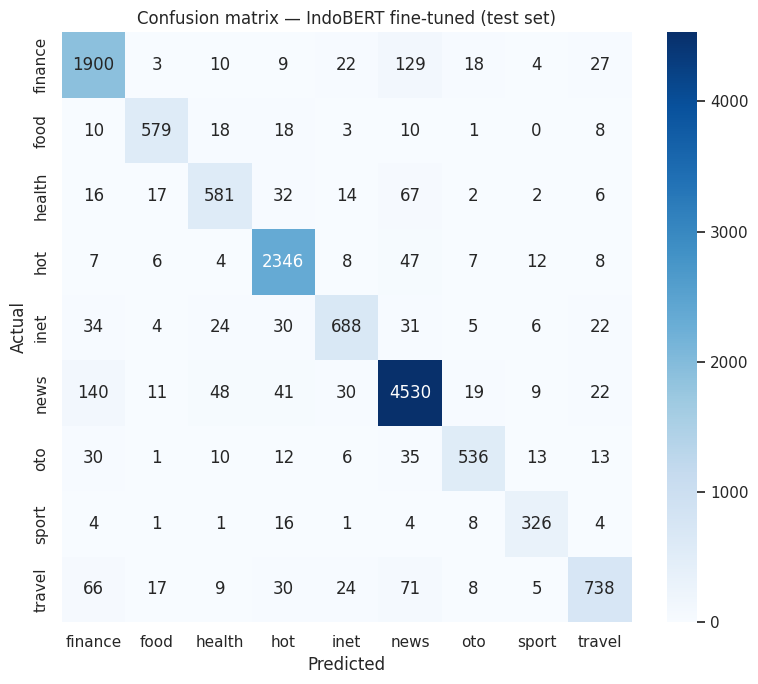

In [11]:
indobert_report, indobert_cm, indobert_labels = evaluate_indobert(
    trainer, test_df, indobert_tokenizer, label2id, id2label
)

print('=== Test set (IndoBERT) ===')
print(f"Accuracy: {indobert_report['accuracy']:.4f}")
print(f"Macro F1: {indobert_report['macro avg']['f1-score']:.4f}")
print()

indobert_per_class = pd.DataFrame(indobert_report).T.loc[indobert_labels, ['precision', 'recall', 'f1-score', 'support']]
print('Per-class metrics (test set):')
print(indobert_per_class.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(indobert_cm, annot=True, fmt='d', cmap='Blues', xticklabels=indobert_labels, yticklabels=indobert_labels, ax=ax)
ax.set_title('Confusion matrix — IndoBERT fine-tuned (test set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix_indobert.png', dpi=150, bbox_inches='tight')
plt.show()


### Publishing the fine-tuned model

`models/indobert-news/` is gitignored (weights exceed the 100 MB commit limit). Push it to the HuggingFace Hub instead so `app.py` can load it at inference time:

```python
trainer.model.push_to_hub("aljuhaeda/indonewsclassifier-indobert")
indobert_tokenizer.push_to_hub("aljuhaeda/indonewsclassifier-indobert")
```

Requires `huggingface-cli login` (or `notebook_login()`) with a write token first.

## 6. Evaluation & comparison

In [13]:
tfidf_vocab_size = len(baseline_pipeline.named_steps['tfidf'].vocabulary_)
logreg_coef = baseline_pipeline.named_steps['clf'].coef_
baseline_n_params = logreg_coef.size + baseline_pipeline.named_steps['clf'].intercept_.size

indobert_n_params = sum(p.numel() for p in trainer.model.parameters())

comparison = pd.DataFrame(
    {
        "Model": ["TF-IDF + Logistic Regression", "IndoBERT (fine-tuned)"],
        "Accuracy": [test_report["accuracy"], indobert_report["accuracy"]],
        "Macro F1": [test_report["macro avg"]["f1-score"], indobert_report["macro avg"]["f1-score"]],
        "Trainable params": [f"{baseline_n_params:,} (TF-IDF vocab {tfidf_vocab_size:,} x {len(labels)} classes)", f"{indobert_n_params:,}"],
        "Training hardware": ["Laptop CPU, seconds", "Colab T4 GPU, 3 epochs"],
    }
)
comparison[["Accuracy", "Macro F1"]] = comparison[["Accuracy", "Macro F1"]].round(4)
comparison


,Model,Accuracy,Macro F1,Trainable params,Training hardware
0,TF-IDF + Logistic Regression,0.8279,0.8000,"180,009 (TF-IDF vocab 20,000 x 9 classes)","Laptop CPU, seconds"
1,IndoBERT (fine-tuned),0.8966,0.8705,"124,448,265","Colab T4 GPU, 3 epochs"


### Comparison discussion

- **IndoBERT wins clearly on macro-F1**: 0.8705 vs. the baseline's 0.8000 (+0.0705 absolute, +8.8% relative), and accuracy jumps from 82.79% to 89.66% (+6.87 points).
- **The gain is broad, not concentrated in one class.** Every single category improved — `health` (0.692 → 0.806 F1) and `travel` (0.738 → 0.813) were the baseline's weakest classes and saw the largest jumps, since a contextual model can tell "virus corona" mentioned in a health headline apart from the same phrase in a travel headline, where TF-IDF just sees identical bag-of-words features. `oto` (0.768 → 0.851) and `hot` (0.899 → 0.942) improved too. No class regressed.
- **`news` recall improved from 0.806 to 0.934** (confusion matrix: 3,901 → 4,530 correctly classified out of 4,850) — IndoBERT is noticeably better at recognizing the catch-all "news" category instead of scattering it into finance/health/travel, which was the baseline's single biggest error source.
- **Does ~700x more parameters (124.4M vs. 180K) justify the gain here?** For a portfolio/benchmark context, yes — the accuracy gap is large enough to be a legitimate "transformers help" result, not noise. For a real production system with tight latency/cost constraints, it's a genuine trade-off: the baseline trains in seconds on a laptop CPU and needs no GPU to serve, while IndoBERT needs a GPU to fine-tune (Colab T4, ~15 min for 3 epochs) and is meaningfully slower per-prediction on CPU at inference time — noticeable in the Streamlit app if it's run without GPU access, though still well under a second per single title.
- **Practical takeaway**: if inference volume is low and latency isn't critical (e.g. a demo, or moderate-throughput backend), IndoBERT's macro-F1 gain is worth it. If serving needs to be cheap/fast/CPU-only at scale, the TF-IDF baseline is a legitimate choice at ~8 points less accuracy.